In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import psutil
import os
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    roc_auc_score, 
    roc_curve, 
    auc,
    f1_score
)
from sklearn.preprocessing import label_binarize

# Helper function to measure current memory usage in MB
def get_memory_usage():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 * 1024)

print("Setup Complete.")

Setup Complete.


In [2]:
# 1. Load Data
data = np.load('../data/fashion_data_complete.npz')
X_test = data['X_test']
y_test = data['y_test']
class_names = data['class_names']

# 2. Define Model Paths
model_files = {
    "k-NN": "../models/knn_fashion_model.joblib",
    "SVM": "../models/svm_fashion_model.joblib",
    "Random Forest": "../models/random_forest_fashion_model.joblib",
    "MLP": "../models/mlp_fashion_model.joblib"
}

# 3. Load Models into dictionary
models = {}
for name, file in model_files.items():
    try:
        models[name] = joblib.load(file)
        print(f"Successfully Loaded {name}")
    except Exception as e:
        print(f"Warning: Could not load {name} from {file}. Error: {e}")

y_test_binarized = label_binarize(y_test, classes=range(10))

Successfully Loaded k-NN
Successfully Loaded SVM
Successfully Loaded Random Forest
Successfully Loaded MLP



==================== k-NN ====================
              precision    recall  f1-score   support

 T-shirt/top       0.79      0.86      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.78      0.76      0.77      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.78      0.80      0.79      1000
      Sandal       0.98      0.83      0.90      1000
       Shirt       0.64      0.64      0.64      1000
     Sneaker       0.88      0.94      0.91      1000
         Bag       0.98      0.94      0.96      1000
  Ankle boot       0.89      0.96      0.92      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


==================== SVM ====================
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.86      0.84      1000
     Trouser       0.99      0.98    

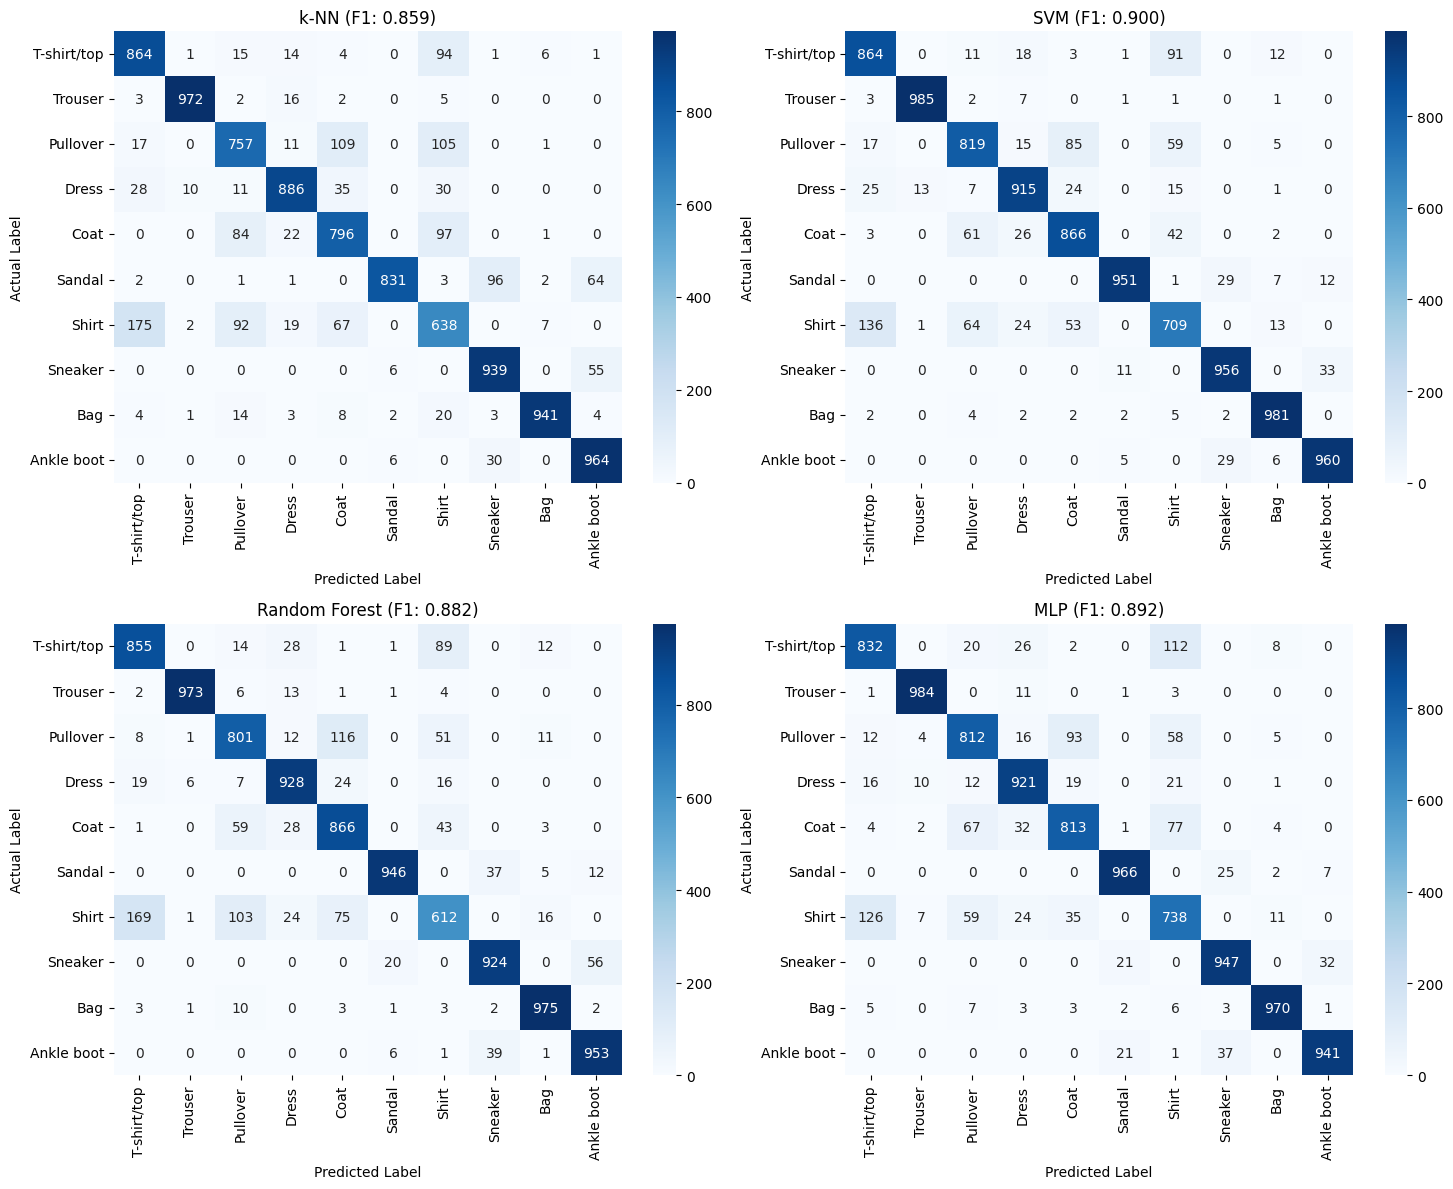

In [3]:
results_summary = []
n_samples = len(X_test)

plt.figure(figsize=(15, 12))

for i, (name, model) in enumerate(models.items()):
    # --- Measure Baseline Memory ---
    mem_before = get_memory_usage()
    
    # --- Start Timer ---
    start_time = time.time()
    
    # Run Prediction
    y_pred = model.predict(X_test)
    
    # --- Stop Timer ---
    end_time = time.time()
    mem_after = get_memory_usage()
    
    # --- Performance Calculations ---
    total_time = end_time - start_time
    latency = (total_time / n_samples) * 1000 # ms per sample
    mem_diff = max(0, mem_after - mem_before) # RAM increase during prediction
    
    # --- Metrics ---
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    # Handle Probability for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)
        y_score = (y_score - y_score.min()) / (y_score.max() - y_score.min())

    roc_auc = roc_auc_score(y_test, y_score, multi_class='ovr', average='macro')
    
    # Save Results
    results_summary.append({
        "Model": name,
        "Accuracy": acc,
        "Macro F1": f1_macro,
        "ROC-AUC": roc_auc,
        "Inference Time (s)": round(total_time, 4),
        "Latency (ms/sample)": round(latency, 4),
        "Memory Spike (MB)": round(mem_diff, 2)
    })

    # Output Report
    print(f"\n{'='*20} {name} {'='*20}")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Plot Confusion Matrix
    plt.subplot(2, 2, i+1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} (F1: {f1_macro:.3f})")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [4]:
df_compare = pd.DataFrame(results_summary).sort_values(by='Macro F1', ascending=False)

print("\n--- Summary Performance Comparison ---")
# Reset index for cleaner display
display(df_compare.reset_index(drop=True))


--- Summary Performance Comparison ---


,Model,Accuracy,Macro F1,ROC-AUC,Inference Time (s),Latency (ms/sample),Memory Spike (MB)
0,SVM,0.9006,0.900034,0.993764,99.8981,9.9898,0.18
1,MLP,0.8924,0.892249,0.991769,0.0313,0.0031,13.89
2,Random Forest,0.8833,0.881741,0.991193,0.1383,0.0138,8.45
3,k-NN,0.8588,0.859058,0.970239,6.2828,0.6283,6.35


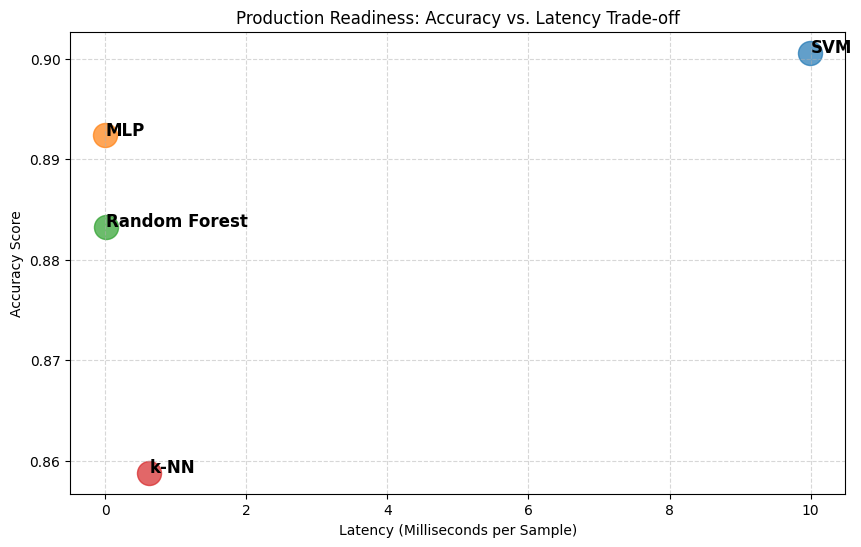

In [5]:
plt.figure(figsize=(10, 6))
for i, row in df_compare.iterrows():
    plt.scatter(row['Latency (ms/sample)'], row['Accuracy'], s=300, alpha=0.7)
    plt.text(row['Latency (ms/sample)'] + 0.005, row['Accuracy'], row['Model'], fontsize=12, fontweight='bold')

plt.xlabel('Latency (Milliseconds per Sample)')
plt.ylabel('Accuracy Score')
plt.title('Production Readiness: Accuracy vs. Latency Trade-off')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

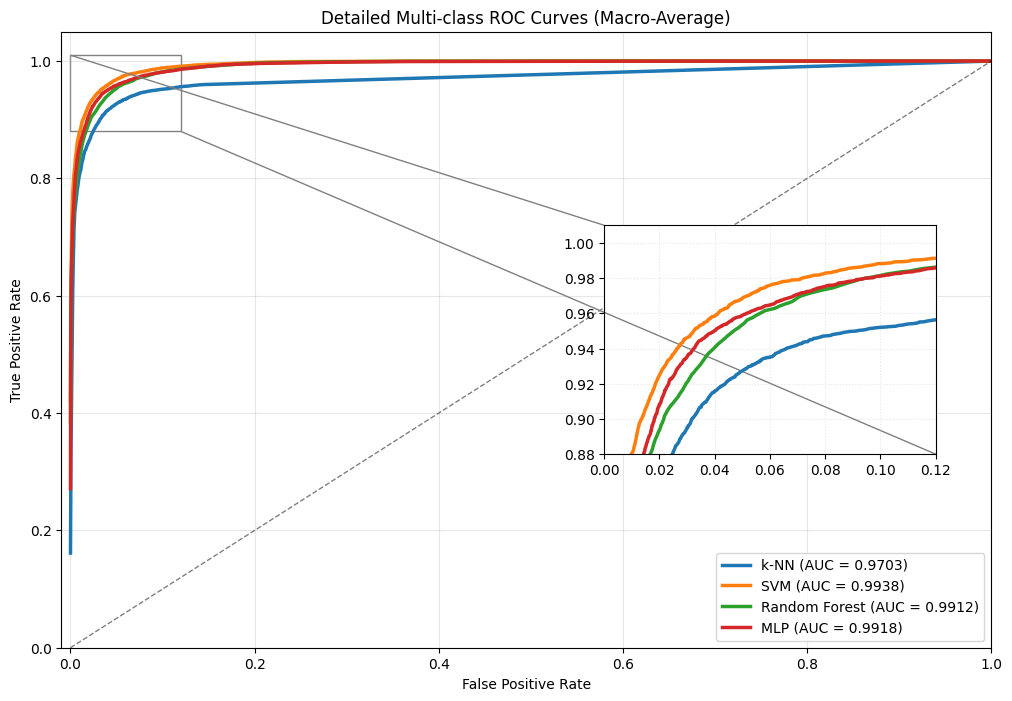

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(12, 8))

# Define zoom area for the top-left corner
x1, x2, y1, y2 = 0.0, 0.12, 0.88, 1.01
axins = zoomed_inset_axes(ax, zoom=3, loc='center right', borderpad=4)

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)
    
    fpr = dict()
    tpr = dict()
    for j in range(10):
        fpr[j], tpr[j], _ = roc_curve(y_test_binarized[:, j], y_score[:, j])

    all_fpr = np.unique(np.concatenate([fpr[j] for j in range(10)]))
    mean_tpr = np.zeros_like(all_fpr)
    for j in range(10):
        mean_tpr += np.interp(all_fpr, fpr[j], tpr[j])
    mean_tpr /= 10
    
    current_auc = auc(all_fpr, mean_tpr)
    
    ax.plot(all_fpr, mean_tpr, label=f'{name} (AUC = {current_auc:.4f})', lw=2.5)
    axins.plot(all_fpr, mean_tpr, lw=2.5)

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Detailed Multi-class ROC Curves (Macro-Average)')
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

# Format Inset
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.grid(alpha=0.3, linestyle=':')
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.show()